In [4]:
# 📊 Netflix Data Analysis Portfolio Project

## 📌 Objective
#Analyze Netflix content trends to extract business insights on growth, genres, countries, and content types.

## 🛠 Tools Used
#Python
#Pandas
#NumPy
#Matplotlib
#Seaborn
#Plotly

In [5]:
# ==========================================
# TAG: IMPORT LIBRARIES
# Purpose: Import required Python libraries
# ==========================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.graph_objects as go
from plotly.subplots import make_subplots
from google.colab import files

In [6]:
# ==========================================
# TAG: DATA UPLOAD
# Purpose: Upload Netflix dataset into Colab
# ==========================================

uploaded = files.upload()

Saving netflix_titles.csv to netflix_titles.csv


In [13]:
# ==========================================
# TAG: LOAD DATA
# Purpose: Read CSV file into pandas DataFrame
# ==========================================

df = pd.read_csv("netflix_titles.csv")
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [14]:
# ==========================================
# TAG: DATA CLEANING & FEATURE ENGINEERING
# ==========================================

# Remove leading and trailing spaces
df['date_added'] = df['date_added'].astype(str).str.strip()

# Convert safely to datetime
df['date_added'] = pd.to_datetime(df['date_added'], errors='coerce')

# Extract year
df['year_added'] = df['date_added'].dt.year

# Extract primary country
df['primary_country'] = df['country'].fillna("Unknown").apply(lambda x: x.split(',')[0])

# Extract primary genre
df['primary_genre'] = df['listed_in'].apply(lambda x: x.split(',')[0])

# Extract numeric duration
df['duration_int'] = df['duration'].str.extract(r'(\d+)')
df['duration_int'] = pd.to_numeric(df['duration_int'], errors='coerce')

In [15]:
# ==========================================
# TAG: ANALYTICAL DATA PREPARATION
# ==========================================

yearly_content = df['year_added'].value_counts().sort_index()
top_countries = df['primary_country'].value_counts().head(10)
genre_year = df.groupby(['year_added', 'primary_genre']).size().unstack()
top_genres = df['primary_genre'].value_counts().head(5).index
movies = df[df['type'] == 'Movie']

In [16]:
# ==========================================
# TAG: NETFLIX INTERACTIVE DASHBOARD
# ==========================================

fig = make_subplots(
    rows=3, cols=2,
    subplot_titles=(
        "Movies vs TV Shows",
        "Content Growth Over Years",
        "Top 10 Countries",
        "Top Genres Trend",
        "Movie Duration Distribution",
        ""
    )
)

# Movies vs TV Shows
type_counts = df['type'].value_counts()
fig.add_trace(go.Bar(x=type_counts.index, y=type_counts.values),
              row=1, col=1)

# Content Growth
fig.add_trace(go.Scatter(x=yearly_content.index,
                         y=yearly_content.values,
                         mode='lines+markers'),
              row=1, col=2)

# Top Countries
fig.add_trace(go.Bar(x=top_countries.values,
                     y=top_countries.index,
                     orientation='h'),
              row=2, col=1)

# Genre Trend
for genre in top_genres:
    fig.add_trace(go.Scatter(x=genre_year.index,
                             y=genre_year[genre],
                             mode='lines',
                             name=genre),
                  row=2, col=2)

# Duration Distribution
fig.add_trace(go.Histogram(x=movies['duration_int']),
              row=3, col=1)

fig.update_layout(
    height=1000,
    width=1200,
    title_text="📊 Netflix Data Analysis Dashboard",
    showlegend=True
)

fig.show()

In [24]:
## 📌 Strategic Insights

#1. Significant content growth observed after 2016.
#2. United States dominates production, with India emerging rapidly.
#3. Drama and International genres show consistent expansion.
#4. TV Shows are growing faster than Movies.
#5. Average movie duration suggests preference for mid-length films.

## 🚀 Strategic Recommendations

#- Expand regional original productions.
#- Invest in episodic content for long-term retention.
#- Diversify into high-growth genres.

In [20]:
# ==========================================
# TAG: YEAR-OVER-YEAR GROWTH ANALYSIS
# Purpose: Calculate annual content growth percentage
# ==========================================

growth_df = yearly_content.pct_change() * 100
growth_df = growth_df.dropna()

growth_df.head()

,count
year_added,
2009.0,0.000000
2010.0,-50.000000
2011.0,1200.000000
2012.0,-76.923077
2013.0,266.666667


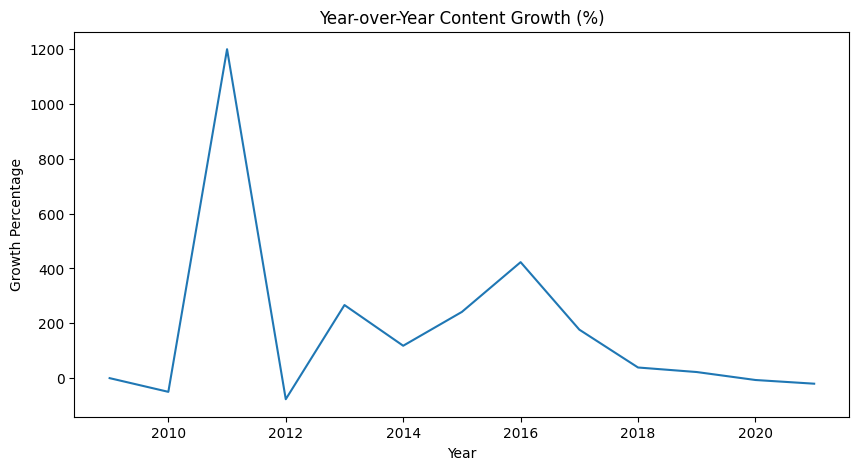

In [25]:
# ==========================================
# TAG: YEAR-OVER-YEAR GROWTH ANALYSIS
# Purpose: Measure Netflix content expansion velocity annually
# ==========================================

growth_df = yearly_content.pct_change() * 100
growth_df = growth_df.dropna()

plt.figure(figsize=(10,5))
plt.plot(growth_df.index, growth_df.values)
plt.title("Year-over-Year Content Growth (%)")
plt.xlabel("Year")
plt.ylabel("Growth Percentage")
plt.show()

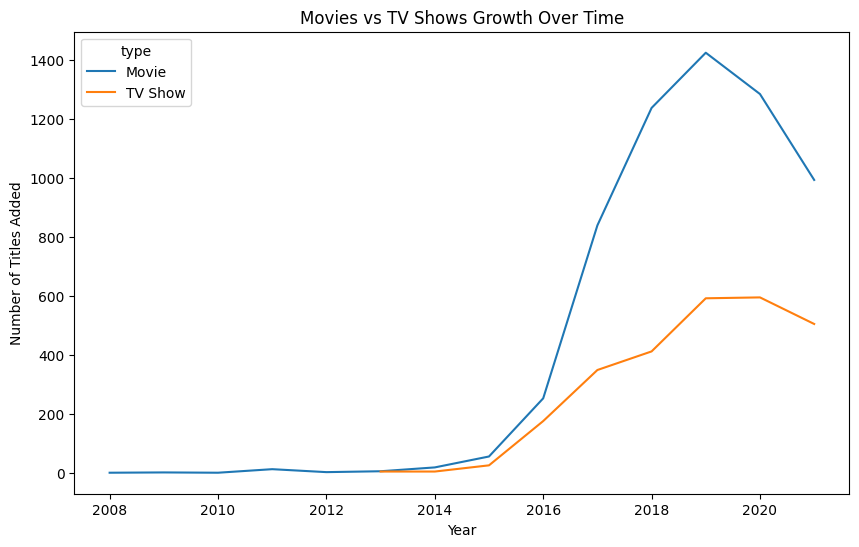

In [26]:
# ==========================================
# TAG: CONTENT TYPE GROWTH COMPARISON
# Purpose: Compare yearly growth of Movies and TV Shows
# ==========================================

content_trend = df.groupby(['year_added', 'type']).size().unstack()

content_trend.plot(figsize=(10,6))
plt.title("Movies vs TV Shows Growth Over Time")
plt.xlabel("Year")
plt.ylabel("Number of Titles Added")
plt.show()

In [27]:
# ==========================================
# TAG: GENRE MARKET CONCENTRATION ANALYSIS
# Purpose: Identify dominant genres and platform dependency risk
# ==========================================

genre_distribution = df['primary_genre'].value_counts(normalize=True) * 100

genre_distribution.head(10)

,proportion
primary_genre,
Dramas,18.167367
Comedies,13.739071
Action & Adventure,9.753605
Documentaries,9.412967
International TV Shows,8.788464
Children & Family Movies,6.869536
Crime TV Shows,4.530487
Kids' TV,4.405586
Stand-Up Comedy,3.792438


In [28]:
# ==========================================
# TAG: COUNTRY DIVERSIFICATION ANALYSIS
# Purpose: Measure content production dependency by region
# ==========================================

country_share = df['primary_country'].value_counts(normalize=True) * 100

top5_country_share = country_share.head(5).sum()

print("Top 5 countries contribute:",
      round(top5_country_share, 2),
      "% of total content")

Top 5 countries contribute: 67.55 % of total content


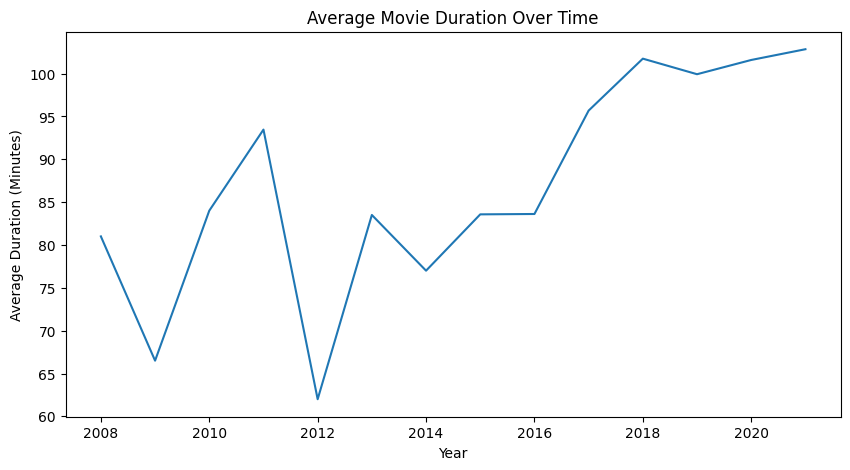

In [29]:
# ==========================================
# TAG: MOVIE DURATION TREND ANALYSIS
# Purpose: Analyze evolution of movie runtime strategy over time
# ==========================================

avg_duration_year = movies.groupby('year_added')['duration_int'].mean()

plt.figure(figsize=(10,5))
plt.plot(avg_duration_year.index, avg_duration_year.values)
plt.title("Average Movie Duration Over Time")
plt.xlabel("Year")
plt.ylabel("Average Duration (Minutes)")
plt.show()

In [ ]:
# 📌 Executive Summary

## 🎯 Project Objective
#The objective of this analysis was to explore Netflix’s content dataset to uncover strategic insights related to growth patterns, genre dominance, geographical distribution, and content type evolution.

#---

## 📊 Key Findings

### 📈 Growth Acceleration
#Netflix experienced rapid content expansion post-2016, indicating aggressive global scaling.

### 🎬 TV Shows vs Movies
#TV Shows have shown faster growth compared to Movies, suggesting a strategic focus on episodic content to increase user retention.

### 🌍 Geographic Concentration
#The United States dominates content production, though emerging markets like India show strong upward trends.

### 🎭 Genre Concentration
#Drama and International genres lead the platform, indicating audience preference patterns but also potential genre concentration risk.

### ⏱ Duration Strategy
#Average movie duration trends indicate preference toward mid-length films, aligning with digital consumption behavior.

#---

## 🚀 Strategic Recommendations

#- Expand original productions in emerging international markets.
#- Continue investing in serialized content for long-term engagement.
#- Diversify into underrepresented genres to reduce concentration risk.
#- Explore shorter-format content for mobile-first audiences.

#---

## 🏆 Business Impact

#This analysis demonstrates how data-driven insights can guide strategic decisions in:
#- Content investment planning
#- Market expansion strategy
#- Portfolio diversification
#- Audience retention optimization